In [10]:
from cogent3.maths.matrix_exponential_integration import expected_number_subs
import matplotlib.pyplot as plt
import paths
import pandas as pd

import pickle

import re

In [11]:
#function to parse the alignment lenght

def parse_alignment_length(s: str, fmt: str = "{:.6e}") -> str:
    """
    Parse strings like "alignment length: X" and return X formatted in scientific notation.

    Parameters
    - s: input string containing a token like "alignment length: 12345"
    - fmt: a format string compatible with float.format, default "{:.6e}" (6 decimals in exp notation)

    Returns
    - str: the parsed number formatted according to `fmt` (scientific notation by default)

    Raises ValueError if the token is not found.
    """
    m = re.search(r'alignment\s*length\s*:\s*([0-9]+(?:\.[0-9]+)?)', s, re.I)
    if not m:
        raise ValueError(f"Can't parse alignment length from: {s!r}")
    token = m.group(1)
    # normalize to float for consistent formatting
    value = float(token)
    return fmt.format(value)

## Intergenic Ancestral Repeats (IGAR)

In [13]:
region = "intergenicAR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_IGAR=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

IGAR_motif_probs = result_IGAR.lf.get_param_value("mprobs")
humanQ_IGAR = result_IGAR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_IGAR = expected_number_subs(IGAR_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS IGAR: ")
print(humanENS_IGAR)

result_IGAR.lf

alignment lenght  1.880700e+04
Human ENS IGAR: 
0.42026146921228


GN
log-likelihood = -75674.1368
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Human         root        0.42    0.78    0.63    0.97    0.74    0.48
Chimpanzee    root        0.60    1.12    0.79    1.31    0.99    0.79
Orangutan     root          NA      NA      NA      NA      NA      NA
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
0.81    0.97    0.60    0.66    0.78    0.57
1.24    1.11    0.79    0.73    1.31    0.97
  NA      NA      NA      NA      NA      NA
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.26    0.24    0.24    0.26
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.45
T        C           0.19
T        A           0.19
T        G           0.17
C        T           0.21
C        C           0.42
C        A           0.18
C        G           0.19
A        T           0.19
A        C           0.18
A        A           0.47
A        G           0.17
G        T           0.18
G        C           0.19
G        A           0.19
G        G           0.44
-------------------------

## CDS

In [14]:
region = "cds/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_cds=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

cds_motif_probs = result_cds.lf.get_param_value("mprobs")
humanQ_cds = result_cds.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_cds = expected_number_subs(cds_motif_probs, humanQ_cds, t=1.0)
#This is the ENS of cdss if selection was the same as on IGAR. Instead of using the cds Q matrix humanQ_cds, I use the IGAR Q humanQ_IGAR
humanENS_cds_IGARQ = expected_number_subs(cds_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS cds: ")
print(humanENS_cds)
print("Human ENS cds with IGAR Q: ")
print(humanENS_cds_IGARQ)

result_cds.lf

alignment lenght  5.362670e+05
Human ENS cds: 
0.004074527134641968
Human ENS cds with IGAR Q: 
0.41658823762879976


GN
log-likelihood = -831797.8472
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Human         root        0.00    1.26    5.07    0.68    1.60    1.81
Chimpanzee    root        0.01    1.28    2.23    0.94    1.00    1.32
Orangutan     root          NA      NA      NA      NA      NA      NA
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
8.89    7.38    1.53    1.34    0.77    3.90
3.24    2.82    1.82    1.12    0.77    2.45
  NA      NA      NA      NA      NA      NA
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.22    0.30    0.29    0.19
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.98
T        C           0.01
T        A           0.00
T        G           0.00
C        T           0.01
C        C           0.98
C        A           0.00
C        G           0.00
A        T           0.00
A        C           0.00
A        A           0.98
A        G           0.01
G        T           0.00
G        C           0.00
G        A           0.01
G        G           0.98
-------------------------

## Introns

In [15]:
region = "introns_nonUTR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_introns=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_introns.lf.get_param_value("mprobs")
humanQ_introns = result_introns.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_introns = expected_number_subs(intron_motif_probs, humanQ_introns, t=1.0)
#This is the ENS of introns if selection was the same as on IGAR. Instead of using the introns Q matrix humanQ_introns, I use the IGAR Q humanQ_IGAR
humanENS_introns_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS introns: ")
print(humanENS_introns)
print("Human ENS introns with IGAR Q: ")
print(humanENS_introns_IGARQ)

result_introns.lf


alignment lenght  2.535200e+04
Human ENS introns: 
0.20608587363651631
Human ENS introns with IGAR Q: 
0.4188603456511659


GN
log-likelihood = -91266.9783
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.19    1.27    1.43    1.40    1.16    1.13
Human         root        0.21    1.06    1.08    0.77    0.85    0.69
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
1.30    0.98    1.10    1.03    1.54    1.51
0.73    0.81    0.84    0.76    0.85    0.80
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.24    0.26    0.26    0.24
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.49
T        C           0.17
T        A           0.18
T        G           0.16
C        T           0.17
C        C           0.53
C        A           0.14
C        G           0.17
A        T           0.18
A        C           0.16
A        A           0.49
A        G           0.17
G        T           0.15
G        C           0.16
G        A           0.16
G        G           0.54
-------------------------

## 5' UTR

In [16]:
region = "introns5UTR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_5UTR=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_5UTR.lf.get_param_value("mprobs")
humanQ_5UTR = result_5UTR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_5UTR = expected_number_subs(intron_motif_probs, humanQ_5UTR, t=1.0)
#This is the ENS of 5UTR if selection was the same as on IGAR. Instead of using the 5UTR Q matrix humanQ_5UTR, I use the IGAR Q humanQ_IGAR
humanENS_5UTR_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS 5UTR: ")
print(humanENS_5UTR)
print("Human ENS 5UTR with IGAR Q: ")
print(humanENS_5UTR_IGARQ)

result_5UTR.lf

alignment lenght  2.177800e+04
Human ENS 5UTR: 
0.1301101787818592
Human ENS 5UTR with IGAR Q: 
0.41918220370844017


GN
log-likelihood = -70884.5429
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.16    0.95    1.13    0.94    0.85    0.89
Human         root        0.13    0.83    1.29    1.10    0.98    1.04
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
1.13    0.81    0.80    1.06    1.12    1.02
1.13    1.10    1.12    0.77    1.15    0.94
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.24    0.25    0.26    0.24
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.66
T        C           0.12
T        A           0.11
T        G           0.11
C        T           0.11
C        C           0.66
C        A           0.10
C        G           0.12
A        T           0.11
A        C           0.11
A        A           0.66
A        G           0.12
G        T           0.11
G        C           0.12
G        A           0.12
G        G           0.66
-------------------------

## 3' UTR

In [17]:
region = "introns3UTR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_3UTR=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_3UTR.lf.get_param_value("mprobs")
humanQ_3UTR = result_3UTR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_3UTR = expected_number_subs(intron_motif_probs, humanQ_3UTR, t=1.0)
#This is the ENS of 3UTR if selection was the same as on IGAR. Instead of using the 3UTR Q matrix humanQ_3UTR, I use the IGAR Q humanQ_IGAR
humanENS_3UTR_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS 3UTR: ")
print(humanENS_3UTR)
print("Human ENS 3UTR with IGAR Q: ")
print(humanENS_3UTR_IGARQ)

result_3UTR.lf

alignment lenght  1.123500e+04
Human ENS 3UTR: 
0.18811442892089095
Human ENS 3UTR with IGAR Q: 
0.4183413138719079


GN
log-likelihood = -40460.6850
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.26    1.06    1.19    1.14    0.96    1.29
Human         root        0.19    0.93    1.02    0.48    0.60    0.57
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
1.07    1.17    1.08    0.76    1.45    1.16
0.62    0.72    0.93    0.58    0.47    0.87
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.24    0.27    0.27    0.23
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.56
T        C           0.15
T        A           0.15
T        G           0.14
C        T           0.14
C        C           0.57
C        A           0.13
C        G           0.16
A        T           0.14
A        C           0.14
A        A           0.57
A        G           0.15
G        T           0.14
G        C           0.16
G        A           0.15
G        G           0.55
-------------------------

## Introns Ancestral Repeats (IntronAR)

In [18]:
region = "intronsAR/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_intronsAR=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intronsAR_motif_probs = result_intronsAR.lf.get_param_value("mprobs")
humanQ_intronsAR = result_intronsAR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_intronsAR = expected_number_subs(intronsAR_motif_probs, humanQ_intronsAR, t=1.0)
#This is the ENS of intronsAR if selection was the same as on IGAR. Instead of using the intronsAR Q matrix humanQ_intronsAR, I use the IGAR Q humanQ_IGAR
humanENS_intronsAR_IGARQ = expected_number_subs(intronsAR_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS intronsAR: ")
print(humanENS_intronsAR)
print("Human ENS intronsAR with IGAR Q: ")
print(humanENS_intronsAR_IGARQ)

#print("Motif probs: ")
#print(intronsAR_motif_probs)

result_intronsAR.lf

alignment lenght  2.493600e+04
Human ENS intronsAR: 
0.34795274230060463
Human ENS intronsAR with IGAR Q: 
0.4189313030964369


GN
log-likelihood = -96020.5171
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Human         root        0.35    0.96    1.06    0.75    0.71    0.86
Chimpanzee    root        0.29    1.00    1.10    1.15    1.05    1.06
Orangutan     root          NA      NA      NA      NA      NA      NA
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
0.66    0.67    0.79    0.67    0.98    0.93
1.17    1.03    1.04    0.79    1.18    1.11
  NA      NA      NA      NA      NA      NA
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.24    0.26    0.27    0.23
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.45
T        C           0.19
T        A           0.19
T        G           0.18
C        T           0.19
C        C           0.46
C        A           0.17
C        G           0.19
A        T           0.20
A        C           0.17
A        A           0.45
A        G           0.17
G        T           0.16
G        C           0.18
G        A           0.18
G        G           0.48
-------------------------

## Intergenic distal (5kb distal from transcript)

In [19]:
region = "distalIG/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_distalIG=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

distalIG_motif_probs = result_distalIG.lf.get_param_value("mprobs")
humanQ_distalIG = result_distalIG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_distalIG = expected_number_subs(distalIG_motif_probs, humanQ_distalIG, t=1.0)
humanENS_distalIG_IGARQ = expected_number_subs(distalIG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS distalIG: ")
print(humanENS_distalIG)
print("Human ENS distalIG with IGAR Q: ")
print(humanENS_distalIG_IGARQ)

result_distalIG.lf

alignment lenght  8.451000e+03
Human ENS distalIG: 
0.33751068340304863
Human ENS distalIG with IGAR Q: 
0.41848727659946505


GN
log-likelihood = -31349.7256
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Human         root        0.34    0.72    1.26    0.60    0.70    0.75
Chimpanzee    root        0.30    1.10    0.88    0.87    0.85    1.00
Orangutan     root          NA      NA      NA      NA      NA      NA
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
0.90    0.96    0.78    1.00    0.94    0.94
0.90    0.88    0.88    0.89    1.10    1.02
  NA      NA      NA      NA      NA      NA
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.24    0.26    0.28    0.22
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.61
T        C           0.14
T        A           0.10
T        G           0.15
C        T           0.11
C        C           0.63
C        A           0.13
C        G           0.14
A        T           0.10
A        C           0.13
A        A           0.61
A        G           0.16
G        T           0.10
G        C           0.15
G        A           0.13
G        G           0.61
-------------------------

## Intergenic proximal 5' (5kb proximal from transcript start)

In [20]:
region = "proximal5IG/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_proximal5IG=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

proximal5IG_motif_probs = result_proximal5IG.lf.get_param_value("mprobs")
humanQ_proximal5IG = result_proximal5IG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_proximal5IG = expected_number_subs(proximal5IG_motif_probs, humanQ_proximal5IG, t=1.0)
humanENS_proximal5IG_IGARQ = expected_number_subs(proximal5IG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS proximal5IG: ")
print(humanENS_proximal5IG)
print("Human ENS proximal5IG with IGAR Q: ")
print(humanENS_proximal5IG_IGARQ)

result_proximal5IG.lf

alignment lenght  6.374000e+03
Human ENS proximal5IG: 
0.25600597649851553
Human ENS proximal5IG with IGAR Q: 
0.4175481600101135


GN
log-likelihood = -22323.8083
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Human         root        0.26    0.99    1.13    0.56    0.64    1.03
Chimpanzee    root        0.12    1.09    2.75    1.60    1.57    0.75
Orangutan     root          NA      NA      NA      NA      NA      NA
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
0.83    0.73    1.03    0.68    0.43    1.03
0.95    1.11    1.23    1.66    1.26    2.18
  NA      NA      NA      NA      NA      NA
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.22    0.28    0.29    0.22
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.57
T        C           0.17
T        A           0.11
T        G           0.15
C        T           0.14
C        C           0.57
C        A           0.12
C        G           0.16
A        T           0.13
A        C           0.15
A        A           0.55
A        G           0.17
G        T           0.11
G        C           0.17
G        A           0.15
G        G           0.57
-------------------------

## Intergenic proximal 3' (5kb proximal from transcript end)

In [21]:
region = "proximal3IG/chrm22/"
folder_in = paths.DATA_HUMCHIMPORANGOR114 + region
file_in = folder_in + "sm_output/singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_proximal3IG=pickle.load(infile)

file_in = folder_in + "singlent_filtered_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

proximal3IG_motif_probs = result_proximal3IG.lf.get_param_value("mprobs")
humanQ_proximal3IG = result_proximal3IG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_proximal3IG = expected_number_subs(proximal3IG_motif_probs, humanQ_proximal3IG, t=1.0)
humanENS_proximal3IG_IGARQ = expected_number_subs(proximal3IG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS proximal3IG: ")
print(humanENS_proximal3IG)
print("Human ENS proximal3IG with IGAR Q: ")
print(humanENS_proximal3IG_IGARQ)

result_proximal3IG.lf

alignment lenght  3.045000e+03
Human ENS proximal3IG: 
0.29234385783741546
Human ENS proximal3IG with IGAR Q: 
0.41762444434927604


GN
log-likelihood = -11447.9164
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Human         root        0.29    1.40    1.06    0.60    0.69    0.84
Chimpanzee    root        0.36    1.54    3.06    1.63    1.00    1.45
Orangutan     root          NA      NA      NA      NA      NA      NA
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
0.41    0.90    0.34    0.83    0.26    0.92
1.29    2.09    1.42    1.20    1.70    1.98
  NA      NA      NA      NA      NA      NA
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.22    0.28    0.28    0.22
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.57
T        C           0.15
T        A           0.16
T        G           0.13
C        T           0.13
C        C           0.58
C        A           0.14
C        G           0.15
A        T           0.14
A        C           0.14
A        A           0.55
A        G           0.18
G        T           0.16
G        C           0.16
G        A           0.12
G        G           0.55
-------------------------

Text(0, 0.5, 'Constraint')

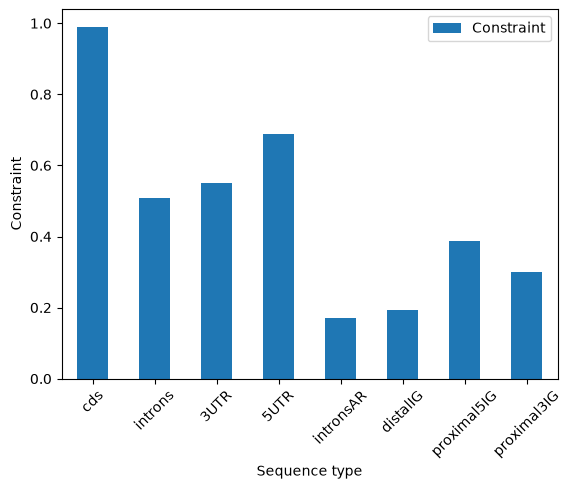

In [22]:
Constraint_data = pd.DataFrame([
    ['cds', (humanENS_cds_IGARQ - humanENS_cds)/humanENS_cds_IGARQ],
    ['introns', (humanENS_introns_IGARQ - humanENS_introns)/humanENS_introns_IGARQ],
    ['3UTR', (humanENS_3UTR_IGARQ - humanENS_3UTR)/humanENS_3UTR_IGARQ],
    ['5UTR', (humanENS_5UTR_IGARQ - humanENS_5UTR)/humanENS_5UTR_IGARQ],
    ['intronsAR', (humanENS_intronsAR_IGARQ - humanENS_intronsAR)/humanENS_intronsAR_IGARQ],
    ['distalIG', (humanENS_distalIG_IGARQ - humanENS_distalIG)/humanENS_distalIG_IGARQ],
    ['proximal5IG', (humanENS_proximal5IG_IGARQ - humanENS_proximal5IG)/humanENS_proximal5IG_IGARQ],
    ['proximal3IG', (humanENS_proximal3IG_IGARQ - humanENS_proximal3IG)/humanENS_proximal3IG_IGARQ]
    ],
    columns = ['Sequence type', 'Constraint'])


Constraint_data.plot(
    x='Sequence type',
    kind = 'bar',
    rot=45)
plt.ylabel('Constraint')

In [24]:
#Constraint_data.to_csv("Output_data/Constraint_perregion.csv", index=False)
Constraint_data

,Sequence type,Constraint
0,cds,0.990219
1,introns,0.507984
2,3UTR,0.550333
3,5UTR,0.689609
4,intronsAR,0.169428
5,distalIG,0.193498
6,proximal5IG,0.386883
7,proximal3IG,0.299984
